# 05 Customer Clustering

# Customer Clustering

## Objective

Customer clustering aims to group customers with similar purchasing behavior without predefined labels.

Unlike RFM segmentation, clustering uses machine learning algorithms to discover hidden customer patterns.

The objective is to identify groups of customers that behave similarly in terms of:

- Purchase recency
- Purchase frequency
- Spending behavior

These clusters can support:
- Personalized marketing
- Customer retention
- Customer value analysis
- Recommendation strategies

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [5]:
# load the RFM features
df_rfm = pd.read_csv(r"D:\retail-projects\online-retail-analysis\data\processed\rfm_features.csv")
df_rfm.head()

,Recency,Frequency,Monetary
0,326,12,77556.46
1,2,8,4921.53
2,75,5,2019.40
3,19,4,4428.69
4,310,1,334.40


In [6]:
df_cluster = df_rfm.copy()

features = [
    "Recency",
    "Frequency",
    "Monetary"
]

X = df_cluster[features]

In [7]:
X

,Recency,Frequency,Monetary
0,326,12,77556.46
1,2,8,4921.53
2,75,5,2019.40
3,19,4,4428.69
4,310,1,334.40
...,...,...,...
5872,4,22,2664.90
5873,432,1,461.68
5874,661,1,427.00
5875,477,2,1296.43


In [8]:
X.describe()

,Recency,Frequency,Monetary
count,5877.000000,5877.000000,5877.000000
mean,201.259656,6.290114,2952.761948
std,209.283194,13.010301,14439.912853
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.240000
50%,96.000000,3.000000,867.110000
75%,380.000000,7.000000,2247.720000
max,739.000000,398.000000,580987.040000


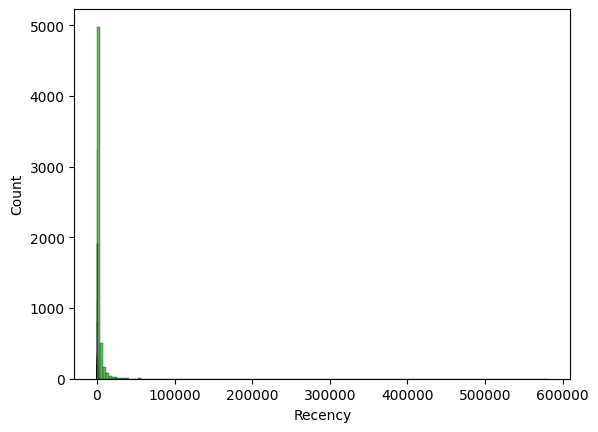

In [9]:
import seaborn as sns

for col in X.columns:
    sns.histplot(X[col])

In [10]:
# skewed distribution, apply log transformation

X["Recency"] = np.log1p(X["Recency"])
X["Frequency"] = np.log1p(X["Frequency"])
X["Monetary"] = np.log1p(X["Monetary"])

In [13]:
# apply standard scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# determine optimal number of clusters using elbow method
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

Text(0, 0.5, 'Inertia')

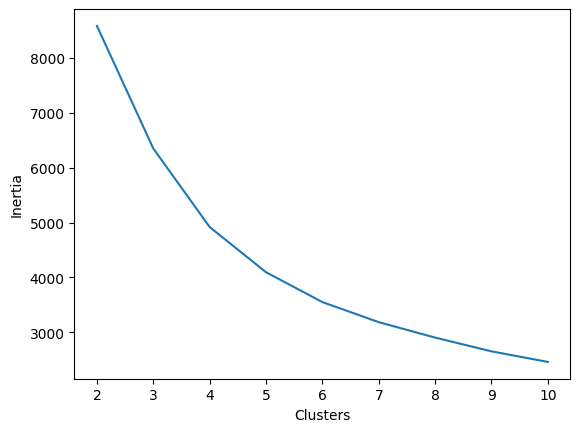

In [ ]:
# plot the inertia values
plt.plot(
    range(2,11),
    inertia
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")

In [ ]:
# from the plot, we can see that the elbow point is around 5 clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(
    X_scaled
)

df_cluster["Cluster"] = clusters

In [ ]:
# analyze cluster characteristics
cluster_summary = (
    df_cluster
    .groupby("Cluster")[
        features
    ]
    .mean()
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,417.116739,1.245831,258.387098
1,18.053648,32.555794,20587.448528
2,48.877234,9.104118,3632.301211
3,32.486014,2.525350,680.723288
4,293.173402,3.800882,1387.055946


# Customer Clustering Analysis

## Cluster Interpretation

Customer clustering was performed using customer purchasing behavior represented by the RFM features (**Recency, Frequency, and Monetary**). The objective was to discover groups of customers with similar behavioral patterns using an unsupervised learning approach.

The resulting clusters reveal clear differences in customer engagement, purchase frequency, and spending levels.

---

### Cluster 0 — Lost Customers

Average Profile:

- Recency: 417 days
- Frequency: 1.25 purchases
- Monetary: 258

Interpretation:

This cluster contains customers who have not purchased recently and historically demonstrated low purchasing activity and low spending levels.

Business Actions:

- Run low-cost reactivation campaigns.
- Reduce marketing investment for this group.
- Use broad promotional strategies only.

---

### Cluster 1 — VIP Customers

Average Profile:

- Recency: 18 days
- Frequency: 32.56 purchases
- Monetary: 20,587

Interpretation:

This cluster represents the highest-value customers. They purchase recently, purchase frequently, and generate the highest revenue.

Business Actions:

- Provide loyalty rewards.
- Offer premium experiences.
- Prioritize retention initiatives.
- Develop personalized marketing campaigns.

---

### Cluster 2 — Loyal Customers

Average Profile:

- Recency: 49 days
- Frequency: 9.10 purchases
- Monetary: 3,632

Interpretation:

These customers maintain strong purchasing behavior and contribute meaningful revenue but are not as dominant as VIP customers.

Business Actions:

- Strengthen loyalty programs.
- Promote cross-selling opportunities.
- Encourage long-term retention.

---

### Cluster 3 — New / Growing Customers

Average Profile:

- Recency: 32 days
- Frequency: 2.53 purchases
- Monetary: 681

Interpretation:

This cluster includes recently active customers who have not yet developed strong purchasing frequency.

Business Actions:

- Encourage repeat purchases.
- Offer onboarding promotions.
- Increase engagement through targeted communication.

---

### Cluster 4 — Needs Reactivation

Average Profile:

- Recency: 293 days
- Frequency: 3.80 purchases
- Monetary: 1,387

Interpretation:

These customers previously demonstrated purchasing activity but have become inactive over time.

Business Actions:

- Launch win-back campaigns.
- Send personalized reminders.
- Offer time-sensitive incentives.

---


In [ ]:
# assign cluster names based on characteristics
cluster_names = {
    0: "Lost Customers",
    1: "VIP Customers",
    2: "Loyal Customers",
    3: "New Customers",
    4: "Needs Reactivation"
}

df_cluster["Cluster_Name"] = (
    df_cluster["Cluster"]
    .map(cluster_names)
)

## Overall Business Insights

The clustering results indicate a healthy separation between high-value customers and inactive customers.

The business maintains a valuable group of highly engaged customers while also presenting opportunities for customer reactivation and loyalty development.



In [ ]:
# save the model and cluster assignments

import pickle

with open(
    r"D:\retail-projects\online-retail-analysis\models\segmentation\kmeans.pkl",
    "wb"
) as f:
    pickle.dump(kmeans, f)

with open(
    r"D:\retail-projects\online-retail-analysis\models\segmentation\scaler.pkl",
    "wb"
) as f:
    pickle.dump(scaler, f)